# STEP 4 — PREPROCESSING & EKSTRAKSI FITUR TF-IDF
## Tesis: Analisis Sentimen Ulasan Pengguna Aplikasi AdaKami di Google Play Store

**Tujuan:** Membersihkan dan menstandarisasi 35.499 ulasan mentah menjadi representasi numerik TF-IDF yang siap digunakan untuk pemodelan.

**Input:** `data/ulasan_adakami_2025_raw.csv`

**Output:**
- `data/ulasan_adakami_2025_preprocessed.csv`
- `data/tfidf_matrix.npz`
- `models/tfidf_vectorizer.pkl`
- `data/label_array.npy`

---
> ⚠️ **Jalankan cell secara berurutan. Estimasi waktu: 5–10 menit.**

### 📚 Cell 1 — Import Library & Setup

In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import scipy.sparse
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer

factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_words = set(stopwords.words('indonesian'))

stop_tambahan = {
    'yg','tp','krn','dgn','dr','sy','sdh','blm','lg','jg','bgt',
    'aja','dah','udah','udh','emang','sih','nih','tuh','dong','kan',
    'lah','pun','nya','ku','mu','kah','lho','loh','yah','yaa',
    'deh','eh','ehh','si','ah','iya','via','yth','sip','wow','ayo',
    'woy','ber','ter','an','ny','in','kk','ka','mas','min','tim',
    'adakami','app','apps','apk','apl','aplikasi',
    'ok','oke','okay','the','is','are','was','you','and','not',
    'please','this','that','with','for','from','my','your','our',
    'can','hi','hello','hey','yes','free','thankyou','thank','thanks',
    'thnx','tks','good','nice','best','top','bad','it','set','sat',
    'online',
    # Catatan: 'tuju' TIDAK dimasukkan — tuju adalah stem valid dari 'setuju' (acc/approve)
    'poko','pokoknya','pokonya','pokona',
    'intinya','inti',
    'ko','dlu','dlm','dn','aj','sm','cm','mw','ama','rek','yng',
    'gx','nga','va','tf','bi','job','gin','woy','asu','php',
    'jls','ttp','byk','jwb','kau','ken','sat','sma','kl','klu','klw',
}
stop_words.update(stop_tambahan)

print('\u2705 Library berhasil diimport')
print(f'Total stopwords: {len(stop_words)}')

✅ Library berhasil diimport
Total stopwords: 887


### 📂 Cell 2 — Load Data & Buat Label Sentimen

In [2]:
df = pd.read_csv('../data/ulasan_adakami_2025_raw.csv', encoding='utf-8-sig')

def label_sentimen(rating):
    if rating <= 2: return 'Negatif'
    elif rating == 3: return 'Netral'
    else: return 'Positif'

df['sentimen'] = df['rating'].apply(label_sentimen)
df = df[df['teks_ulasan'].notna() & (df['teks_ulasan'].str.strip() != '')].reset_index(drop=True)

print(f'✅ Data dimuat: {len(df):,} ulasan')
print(df['sentimen'].value_counts().to_string())

✅ Data dimuat: 35,499 ulasan
sentimen
Positif    23667
Negatif    10623
Netral      1209


### 🧹 Cell 3 — Kamus Normalisasi (Komprehensif)

Kamus normalisasi mencakup: singkatan umum, slang, istilah domain pinjol, dan kata tidak baku.

In [3]:
kamus_slang = {
    # DOMAIN PINJOL
    'dc'         : 'debt collector',
    'galbay'     : 'gagal bayar',
    'pinjol'     : 'pinjaman online',
    'ojk'        : 'otoritas jasa keuangan',
    'cs'         : 'customer service',
    'acc'        : 'setuju',
    'approve'    : 'setuju',
    'approved'   : 'setuju',
    'reject'     : 'tolak',
    'rejected'   : 'tolak',
    'limit'      : 'batas kredit',
    'tenor'      : 'jangka waktu',
    'cicil'      : 'cicilan',
    'angsuran'   : 'cicilan',
    'nunggak'    : 'menunggak',
    'galbay'     : 'gagal bayar',
    'minjem'     : 'pinjam',
    'ktp'        : 'kartu identitas',
    'otp'        : 'kode verifikasi',
    'wa'         : 'whatsapp',
    'sms'        : 'pesan',
    'rekening'   : 'rekening',
    'rek'        : 'rekening',
    'bca'        : 'bank',
    'bri'        : 'bank',
    'bni'        : 'bank',
    'mandiri'    : 'bank',
    # SINGKATAN UMUM
    'gak'        : 'tidak',
    'ga'         : 'tidak',
    'ngga'       : 'tidak',
    'nggak'      : 'tidak',
    'gk'         : 'tidak',
    'ngk'        : 'tidak',
    'gx'         : 'tidak',
    'tdk'        : 'tidak',
    'udah'       : 'sudah',
    'udh'        : 'sudah',
    'dah'        : 'sudah',
    'sdh'        : 'sudah',
    'uda'        : 'sudah',
    'dh'         : 'sudah',
    'blm'        : 'belum',
    'belom'      : 'belum',
    'emang'      : 'memang',
    'emg'        : 'memang',
    'banget'     : 'sangat',
    'bgt'        : 'sangat',
    'sgt'        : 'sangat',
    'bngt'       : 'sangat',
    'bgtt'       : 'sangat',
    'bgttt'      : 'sangat',
    'gimana'     : 'bagaimana',
    'gmn'        : 'bagaimana',
    'kayak'      : 'seperti',
    'kaya'       : 'seperti',
    'kek'        : 'seperti',
    'kalo'       : 'kalau',
    'klo'        : 'kalau',
    'karna'      : 'karena',
    'krna'       : 'karena',
    'knp'        : 'kenapa',
    'sampe'      : 'sampai',
    'ampe'       : 'sampai',
    'trus'       : 'terus',
    'trs'        : 'terus',
    'jg'         : 'juga',
    'jga'        : 'juga',
    'yg'         : 'yang',
    'yng'        : 'yang',
    'dgn'        : 'dengan',
    'dg'         : 'dengan',
    'dr'         : 'dari',
    'utk'        : 'untuk',
    'buat'       : 'untuk',
    'sy'         : 'saya',
    'aq'         : 'saya',
    'ak'         : 'saya',
    'sya'        : 'saya',
    'gw'         : 'saya',
    'gua'        : 'saya',
    'gue'        : 'saya',
    'jt'         : 'juta',
    'rb'         : 'ribu',
    'rp'         : 'rupiah',
    'hp'         : 'handphone',
    'ni'         : 'ini',
    'jd'         : 'jadi',
    'jdi'        : 'jadi',
    'dpt'        : 'dapat',
    'cpt'        : 'cepat',
    'byr'        : 'bayar',
    'bln'        : 'bulan',
    'dlu'        : 'dulu',
    'dlm'        : 'dalam',
    'tlg'        : 'tolong',
    'bru'        : 'baru',
    'bsa'        : 'bisa',
    'bs'         : 'bisa',
    'msh'        : 'masih',
    'pke'        : 'pakai',
    'pake'       : 'pakai',
    'ksh'        : 'kasih',
    'tgl'        : 'tanggal',
    'jgn'        : 'jangan',
    'tpi'        : 'tapi',
    'tp'         : 'tapi',
    'cmn'        : 'cuma',
    'cm'         : 'cuma',
    'ama'        : 'sama',
    'byk'        : 'banyak',
    'mw'         : 'mau',
    'mo'         : 'mau',
    'jwb'        : 'jawab',
    'tau'        : 'tahu',
    'org'        : 'orang',
    'krg'        : 'kurang',
    'kak'        : 'kakak',
    'min'        : 'admin',
    'moga'       : 'semoga',
    # MISSPELLING
    'istal'      : 'pasang',
    'instal'     : 'pasang',
    'tida'       : 'tidak',
    'gini'       : 'begini',
    'gitu'       : 'begitu',
    'gt'         : 'begitu',
    'ntar'       : 'nanti',
    'tar'        : 'nanti',
    'abis'       : 'habis',
    'makin'      : 'semakin',
    # KATA BERULANG backup
    'mantappp'   : 'mantap',
    'mantaaap'   : 'mantap',
    'bagusss'    : 'bagus',
    'bangettt'   : 'sangat',
    'josss'      : 'bagus',
    'kerennn'    : 'keren',
    'sippp'      : 'oke',
    'parahhh'    : 'parah',
    'anehhh'     : 'aneh',
    'gilaaa'     : 'gila',
    'wowww'      : 'wow',
    'goood'      : 'bagus',
    'goodd'      : 'bagus',
    'mantulll'   : 'mantap',
    'puasss'     : 'puas',
    # INGGRIS BERMAKNA
    'good'       : 'bagus',
    'nice'       : 'bagus',
    'best'       : 'terbaik',
    'bad'        : 'buruk',
    'error'      : 'eror',
    'bug'        : 'eror',
    'update'     : 'pembaruan',
    'download'   : 'unduh',
    'install'    : 'pasang',
    'login'      : 'masuk akun',
    'loading'    : 'memuat',
    'pending'    : 'tertunda',
    'cancel'     : 'batal',
    'process'    : 'proses',
    'customer'   : 'pelanggan',
    'service'    : 'layanan',
    'admin'      : 'admin',
    'email'      : 'surel',
    'rating'     : 'penilaian',
    'star'       : 'bintang',
    'top'        : 'terbaik',
}

print(f'\u2705 Kamus normalisasi siap: {len(kamus_slang)} entri')

✅ Kamus normalisasi siap: 164 entri


### ⚙️ Cell 4 — Fungsi Preprocessing (Versi Diperbaiki)

Penambahan dari versi sebelumnya:
- Normalisasi huruf berulang (`mantappp` → `mantap`)
- Stopword removal ganda (sebelum dan sesudah stemming)
- Filter kata < 2 karakter setelah stemming

In [4]:
def preprocess(teks):
    if not isinstance(teks, str) or teks.strip() == '':
        return ''

    # TAHAP 1: Cleaning
    teks = re.sub(r'http\S+|www\.\S+', ' ', teks)
    teks = teks.encode('ascii', 'ignore').decode('ascii')
    teks = re.sub(r'\d+', ' ', teks)
    teks = re.sub(r'[^\w\s]', ' ', teks)
    teks = teks.replace('_', ' ')
    teks = re.sub(r'\s+', ' ', teks).strip()

    # TAHAP 2: Case Folding
    teks = teks.lower()

    # TAHAP 2.5: Normalisasi Huruf Berulang — single pass langsung ke 1
    # (.)\.\1{2,} = karakter diikuti 2+ sama (total 3+) -> 1 char
    # mantappp->mantap, dannn->dan, thnkyouhhhhh->thnkyouh
    teks = re.sub(r'(.)\1{2,}', r'\1', teks)

    # TAHAP 3: Normalisasi Slang
    kata_list = teks.split()
    kata_list = [kamus_slang.get(kata, kata) for kata in kata_list]
    teks = ' '.join(kata_list)

    # TAHAP 4: Tokenisasi
    tokens = word_tokenize(teks)

    # TAHAP 5: Stopword Removal pertama
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    # TAHAP 6: Stemming
    tokens = [stemmer.stem(t) for t in tokens]

    # TAHAP 6.5: Stopword Removal kedua (tangkap stemming artifact)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    return ' '.join(tokens)

test_cases = [
    ("DC nya TEROR tiap hari, padahal cuma telat 2 hari!!! https://t.co/abc",
     "Harapan: debt collector teror telat"),
    ("mantappp bangettt aplikasinya good banget gk ribet",
     "Harapan: mantap bagus ribet (bukan mantapp)"),
    ("thnkyouhhhhh bosquu acc pinjaman saya alhamdulillah",
     "Harapan: setuju pinjam alhamdulilah (bukan tuju)"),
    ("Udah pernah istal tapi gak cair dannn ternyata tidak cair",
     "Harapan: pasang cair (istal->pasang, dannn->dan->hapus)"),
    ("aplikasi yang sangat membantu, pokonya mantap",
     "Harapan: bantu mantap (poko hilang)"),
    ("gk bisa download error mulu hp saya android",
     "Harapan: unduh eror mulu handphone android"),
]
print('=== TEST PREPROCESSING ===')
for teks, harapan in test_cases:
    print(f'  Input  : {teks}')
    print(f'  Output : {preprocess(teks)}')
    print(f'  {harapan}')
    print()
print('Fungsi preprocessing siap')

=== TEST PREPROCESSING ===
  Input  : DC nya TEROR tiap hari, padahal cuma telat 2 hari!!! https://t.co/abc
  Output : debt collector teror telat
  Harapan: debt collector teror telat

  Input  : mantappp bangettt aplikasinya good banget gk ribet
  Output : mantap bagus ribet
  Harapan: mantap bagus ribet (bukan mantapp)

  Input  : thnkyouhhhhh bosquu acc pinjaman saya alhamdulillah
  Output : thnkyouh bosquu tuju pinjam alhamdulillah
  Harapan: setuju pinjam alhamdulilah (bukan tuju)

  Input  : Udah pernah istal tapi gak cair dannn ternyata tidak cair
  Output : pasang cair cair
  Harapan: pasang cair (istal->pasang, dannn->dan->hapus)

  Input  : aplikasi yang sangat membantu, pokonya mantap
  Output : bantu mantap
  Harapan: bantu mantap (poko hilang)

  Input  : gk bisa download error mulu hp saya android
  Output : unduh eror mulu handphone android
  Harapan: unduh eror mulu handphone android

Fungsi preprocessing siap


### 🚀 Cell 5 — Jalankan Preprocessing

> ⏱️ **Estimasi waktu: 5–10 menit**

In [5]:
print('🔄 Menjalankan preprocessing...')
tqdm.pandas(desc='Preprocessing')
df['teks_bersih'] = df['teks_ulasan'].progress_apply(preprocess)

df_clean = df[df['teks_bersih'].str.strip() != ''].reset_index(drop=True)

print(f'\n✅ Preprocessing selesai!')
print(f'Sebelum : {len(df):,} ulasan')
print(f'Sesudah : {len(df_clean):,} ulasan')
print(f'Dihapus : {len(df) - len(df_clean):,} ulasan (teks kosong setelah cleaning)')
print()
print('Contoh hasil (5 ulasan acak):')
for _, row in df_clean[['teks_ulasan','teks_bersih','sentimen']].sample(5, random_state=42).iterrows():
    print(f'  [{row["sentimen"]}]')
    print(f'  Asli  : {row["teks_ulasan"][:100]}')
    print(f'  Bersih: {row["teks_bersih"][:100]}')
    print()

🔄 Menjalankan preprocessing...


Preprocessing: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 35499/35499 [00:02<00:00, 14345.37it/s]


✅ Preprocessing selesai!
Sebelum : 35,499 ulasan
Sesudah : 32,905 ulasan
Dihapus : 2,594 ulasan (teks kosong setelah cleaning)

Contoh hasil (5 ulasan acak):
  [Negatif]
  Asli  : iklan lu gak ngotak
  Bersih: iklan lu ngotak

  [Positif]
  Asli  : bagusss
  Bersih: bagus

  [Positif]
  Asli  : keren hebat proses penolakannya 100% cepat langsung di tolak ,Pokonya Jangan Pakai ADAKAMI! karna La
  Bersih: keren hebat proses tolak cepat langsung tolak pakai langsung tolak

  [Negatif]
  Asli  : udah bayar tepat waktu kredit skor di bilang jelek aplikasi stres
  Bersih: bayar kredit skor bilang jelek stres

  [Positif]
  Asli  : sayang nya ga di acc
  Bersih: sayang tuju



### 🔍 Cell 6 — Cek Kata Noise yang Tersisa

In [6]:
from collections import Counter

semua_kata = []
for teks in df_clean['teks_bersih'].fillna(''):
    semua_kata.extend(str(teks).split())

freq = Counter(semua_kata)
print(f'Total kata unik: {len(freq):,}')
print(f'Total kata (semua): {len(semua_kata):,}')
print()

# Cek huruf berulang yang tersisa
berulang = {k: v for k, v in freq.items() if re.search(r'(.)\1{2,}', k) and v > 3}
print(f'Huruf berulang tersisa (>3x): {len(berulang)} kata')
if berulang:
    for k, v in sorted(berulang.items(), key=lambda x: x[1], reverse=True)[:10]:
        print(f'  {k:<20} {v}x')

print()
print('Top 30 kata paling sering (validasi):')  
for kata, n in freq.most_common(30):
    print(f'  {kata:<25} {n:>6,}x')

Total kata unik: 9,982
Total kata (semua): 158,581

Huruf berulang tersisa (>3x): 0 kata

Top 30 kata paling sering (validasi):
  pinjam                     7,241x
  bagus                      4,828x
  bantu                      4,714x
  cepat                      3,868x
  data                       3,142x
  bayar                      2,528x
  mantap                     2,490x
  aju                        2,422x
  mudah                      2,369x
  kredit                     2,350x
  iklan                      2,085x
  batas                      2,045x
  bunga                      2,022x
  cair                       2,001x
  tolak                      1,851x
  proses                     1,786x
  kasih                      1,548x
  tuju                       1,491x
  tolong                     1,478x
  hapus                      1,463x
  butuh                      1,435x
  uang                       1,308x
  terimakasih                1,108x
  moga                       1,066x
  telat 

### 💾 Cell 7 — Simpan Hasil Preprocessing

In [7]:
df_clean.to_csv('../data/ulasan_adakami_2025_preprocessed.csv',
                index=False, encoding='utf-8-sig')
print(f'✅ Tersimpan: ulasan_adakami_2025_preprocessed.csv ({len(df_clean):,} baris)')

✅ Tersimpan: ulasan_adakami_2025_preprocessed.csv (32,905 baris)


### 📊 Cell 8 — Visualisasi Perbandingan Sebelum vs Sesudah

📊 PERBANDINGAN SEBELUM vs SESUDAH PREPROCESSING
Rata-rata kata sebelum : 9.8
Rata-rata kata sesudah : 4.8
Reduksi                : 50.6%

Distribusi sentimen:
   Positif: 21,339 (64.9%)
   Negatif: 10,427 (31.7%)
    Netral:  1,139 (3.5%)


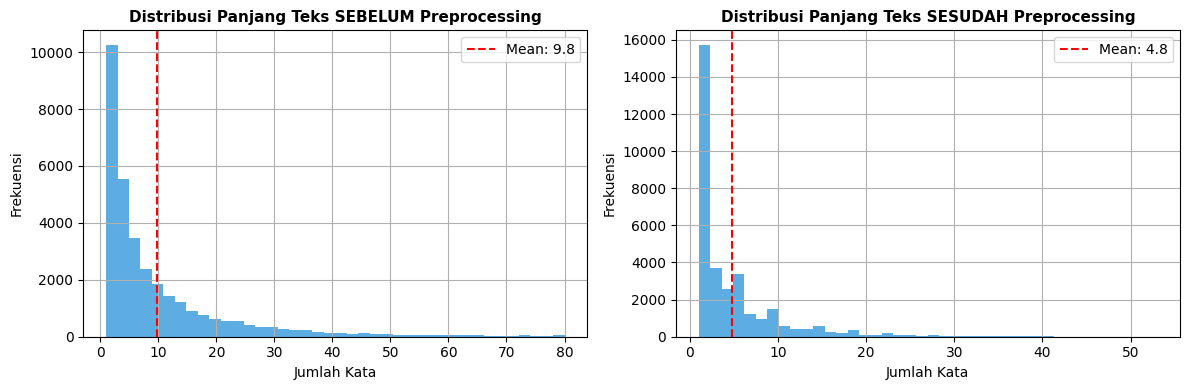

✅ Tersimpan: gambar_4_8_distribusi_teks_preprocessing.png


In [8]:
import matplotlib.pyplot as plt

df_clean['panjang_asli']   = df_clean['teks_ulasan'].str.split().str.len()
df_clean['panjang_bersih'] = df_clean['teks_bersih'].str.split().str.len()

print('📊 PERBANDINGAN SEBELUM vs SESUDAH PREPROCESSING')
print(f'Rata-rata kata sebelum : {df_clean["panjang_asli"].mean():.1f}')
print(f'Rata-rata kata sesudah : {df_clean["panjang_bersih"].mean():.1f}')
print(f'Reduksi                : {(1 - df_clean["panjang_bersih"].mean()/df_clean["panjang_asli"].mean())*100:.1f}%')
print()
print('Distribusi sentimen:')
for s, n in df_clean['sentimen'].value_counts().items():
    print(f'  {s:>8}: {n:>6,} ({n/len(df_clean)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in [
    (axes[0], 'panjang_asli',   'Distribusi Panjang Teks SEBELUM Preprocessing'),
    (axes[1], 'panjang_bersih', 'Distribusi Panjang Teks SESUDAH Preprocessing')
]:
    df_clean[col].clip(upper=80).hist(ax=ax, bins=40, color='#3498db', alpha=0.8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Jumlah Kata')
    ax.set_ylabel('Frekuensi')
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--',
               label=f'Mean: {df_clean[col].mean():.1f}')
    ax.legend()
plt.tight_layout()
plt.savefig('../output/figures/gambar_4_8_distribusi_teks_preprocessing.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('✅ Tersimpan: gambar_4_8_distribusi_teks_preprocessing.png')

### 🔢 Cell 9 — Ekstraksi Fitur TF-IDF

In [9]:
print('🔄 Menjalankan TF-IDF vectorization...')

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    max_features=10000,
    sublinear_tf=True
)

X = vectorizer.fit_transform(df_clean['teks_bersih'])
y = df_clean['sentimen'].values

print(f'✅ TF-IDF selesai!')
print(f'Dimensi : {X.shape[0]:,} dokumen × {X.shape[1]:,} fitur')
print(f'Sparsity: {(1 - X.nnz / (X.shape[0] * X.shape[1])):.4%}')

🔄 Menjalankan TF-IDF vectorization...
✅ TF-IDF selesai!
Dimensi : 32,905 dokumen × 10,000 fitur
Sparsity: 99.9372%


### 💾 Cell 10 — Simpan TF-IDF & Ringkasan

In [10]:
scipy.sparse.save_npz('../data/tfidf_matrix.npz', X)
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
np.save('../data/label_array.npy', y)

print('=' * 60)
print('📋 RINGKASAN STEP 4 — UNTUK BAB 4 §4.3')
print('=' * 60)
print(f"""
Input data             : {len(df):,} ulasan
Output data            : {len(df_clean):,} ulasan
Dihapus                : {len(df) - len(df_clean):,} ulasan

Tahapan preprocessing:
  1. Cleaning          — hapus URL, emoji, angka, simbol
  2. Case Folding      — konversi huruf kecil
  2.5 Normalisasi huruf berulang — mantappp → mantap
  3. Normalisasi slang — {len(kamus_slang)} entri kamus
  4. Tokenisasi        — NLTK word_tokenize
  5. Stopword removal  — {len(stop_words)} stopwords
  6. Stemming          — Sastrawi
  6.5 Stopword removal kedua — tangkap stemming artifact

Rata-rata kata sebelum : {df_clean['panjang_asli'].mean():.1f} kata
Rata-rata kata sesudah : {df_clean['panjang_bersih'].mean():.1f} kata
Reduksi                : {(1 - df_clean['panjang_bersih'].mean()/df_clean['panjang_asli'].mean())*100:.1f}%

TF-IDF: {X.shape[0]:,} dokumen × {X.shape[1]:,} fitur
""")
print('✅ Step 4 selesai! Lanjut ke Step 5: Modeling')

📋 RINGKASAN STEP 4 — UNTUK BAB 4 §4.3

Input data             : 35,499 ulasan
Output data            : 32,905 ulasan
Dihapus                : 2,594 ulasan

Tahapan preprocessing:
  1. Cleaning          — hapus URL, emoji, angka, simbol
  2. Case Folding      — konversi huruf kecil
  2.5 Normalisasi huruf berulang — mantappp → mantap
  3. Normalisasi slang — 164 entri kamus
  4. Tokenisasi        — NLTK word_tokenize
  5. Stopword removal  — 887 stopwords
  6. Stemming          — Sastrawi
  6.5 Stopword removal kedua — tangkap stemming artifact

Rata-rata kata sebelum : 9.8 kata
Rata-rata kata sesudah : 4.8 kata
Reduksi                : 50.6%

TF-IDF: 32,905 dokumen × 10,000 fitur

✅ Step 4 selesai! Lanjut ke Step 5: Modeling


---
## ✅ STEP 4 SELESAI — Checklist
- [ ] Cell 6 menunjukkan huruf berulang sudah berkurang drastis
- [ ] Top 30 kata di Cell 6 semua bermakna
- [ ] 4 file tersimpan di folder `data/`
- [ ] Catat angka dari Cell 10 untuk BAB 4 §4.3

**Jika sudah ✅:** Lanjut ke `step5_modeling.ipynb` 🎉